In [1]:
import tensorflow as tf

import time
import os

from tensorflow.keras.callbacks import EarlyStopping

In [2]:
from sheets.dataloader import MAESTRODataLoader
from sheets.preprocessors import CQTPreprocessor, MELPreprocessor
import sheets.basicmodel as basicmodel
from sheets.dataset_builder import build_tf_dataset

from sheets.utils.pianoroll_audio import numpy_to_midi_object, midi_object_to_playable
import sheets.utils.plotting as plotting

from sheets.constants import *
from sheets.helpers import *

In [3]:
model = basicmodel.initialize_model()
model = basicmodel.compile_model(model)

✅ Model initialized
✅ Model compiled


In [4]:
dataloader = MAESTRODataLoader()
preprocessor = CQTPreprocessor()
train_ds = build_tf_dataset(dataloader, preprocessor, split='train', batch_size=8)
val_ds = build_tf_dataset(dataloader, preprocessor, split='validation', batch_size=8)

[MAESTRODataLoader] train: 70 files found.
[MAESTRODataLoader] validation: 13 files found.


/Users/bastiaanboland/code/BobbyBobster/emilegeagea/sheetify/sheets/dataloader.py:74: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = subset[self.metadata['year'].isin(self.year)]


In [5]:
timestamp = time.strftime("%Y%m%d-%H%M%S")
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=f'./models/{timestamp}.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    save_best_only=True
)

es = EarlyStopping(
    patience=10,
    monitor='val_loss'
)


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    callbacks=[checkpoint_callback],
)

Epoch 1/200
      9/Unknown 12s 1s/step - fbeta: 3.2141e-05 - loss: 0.7016

2026-05-29 13:42:11.475980: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/Users/bastiaanboland/.pyenv/versions/3.10.6/envs/sheetify/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - fbeta: 2.1594e-05 - loss: 0.6806 - val_fbeta: 0.0000e+00 - val_loss: 0.7088
Epoch 2/200


2026-05-29 13:42:12.072478: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - fbeta: 0.0000e+00 - loss: 0.4563 - val_fbeta: 0.0000e+00 - val_loss: 1.3953
Epoch 3/200


...

9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - fbeta: 1.0257e-04 - loss: 0.1744 - val_fbeta: 5.6173e-05 - val_loss: 0.6790
Epoch 34/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - fbeta: 9.1776e-05 - loss: 0.1730 - val_fbeta: 5.6173e-05 - val_loss: 0.6697
Epoch 35/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - fbeta: 1.2957e-04 - loss: 0.1719 - val_fbeta: 5.6173e-05 - val_loss: 0.8042
Epoch 36/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - fbeta: 1.1877e-04 - loss: 0.1727 - val_fbeta: 5.6173e-05 - val_loss: 0.5779
Epoch 37/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - fbeta: 1.2957e-04 - loss: 0.1751 - val_fbeta: 2.8087e-05 - val_loss: 0.5547
Epoch 38/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - fbeta: 1.1877e-04 - loss: 0.1753 - val_fbeta: 5.6173e-05 - val_loss: 0.5442
Epoch 39/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - fbeta: 9.1776e-05 - loss: 0.1732 - val_fbeta: 5.6173e-05 - val_loss: 0.5825
Epoch 40/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - fbeta: 1.4036e-04 - loss: 0.1669 - val_fbeta: 0.0000e+00 - val_lo

2026-05-29 13:53:38.497051: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - fbeta: 1.7815e-04 - loss: 0.1390 - val_fbeta: 0.0000e+00 - val_loss: 0.5339
Epoch 66/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - fbeta: 1.8895e-04 - loss: 0.1392 - val_fbeta: 0.0000e+00 - val_loss: 0.4131
Epoch 67/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - fbeta: 1.6196e-04 - loss: 0.1407 - val_fbeta: 0.0000e+00 - val_loss: 0.5352
Epoch 68/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - fbeta: 2.0515e-04 - loss: 0.1385 - val_fbeta: 0.0000e+00 - val_loss: 0.4634
Epoch 69/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - fbeta: 2.1055e-04 - loss: 0.1352 - val_fbeta: 0.0000e+00 - val_loss: 0.4878
Epoch 70/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - fbeta: 2.1055e-04 - loss: 0.1339 - val_fbeta: 2.8087e-05 - val_loss: 0.4395
Epoch 71/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - fbeta: 2.1594e-04 - loss: 0.1325 - val_fbeta: 0.0000e+00 - val_loss: 0.5271
Epoch 72/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - fbeta: 1.7815e-04 - loss: 0.1324 - val_fbeta: 0.0000e+00 - val_lo

2026-05-29 14:05:59.506389: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - fbeta: 2.2134e-04 - loss: 0.1105 - val_fbeta: 2.8087e-05 - val_loss: 0.3097
Epoch 130/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - fbeta: 2.1594e-04 - loss: 0.1112 - val_fbeta: 2.8087e-05 - val_loss: 0.2783
Epoch 131/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - fbeta: 2.3754e-04 - loss: 0.1111 - val_fbeta: 5.6173e-05 - val_loss: 0.4455
Epoch 132/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - fbeta: 2.7533e-04 - loss: 0.1098 - val_fbeta: 8.4260e-05 - val_loss: 0.2723
Epoch 133/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - fbeta: 2.6993e-04 - loss: 0.1101 - val_fbeta: 1.1235e-04 - val_loss: 0.2608
Epoch 134/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - fbeta: 2.3754e-04 - loss: 0.1089 - val_fbeta: 5.6173e-05 - val_loss: 0.3798
Epoch 135/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - fbeta: 2.7533e-04 - loss: 0.1077 - val_fbeta: 1.1235e-04 - val_loss: 0.2784
Epoch 136/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - fbeta: 2.4834e-04 - loss: 0.1081 - val_fbeta: 1.4043e-04 -

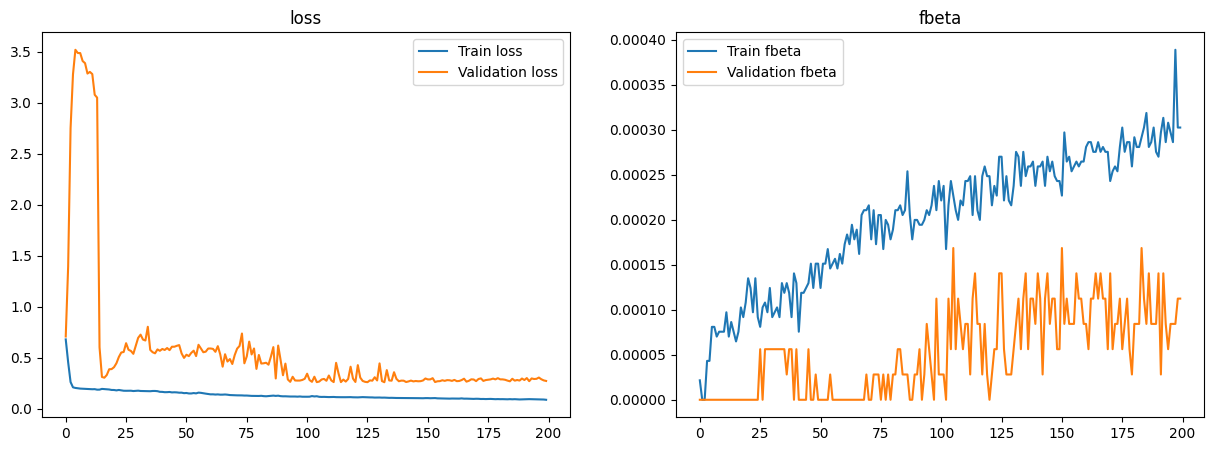

In [6]:
plotting.plot_history(history, metric_name='fbeta')

CQT shape:        (84, 313, 1)
Piano roll shape: (88, 1000)
(1, 84, 313, 1)
(1, 88, 1000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


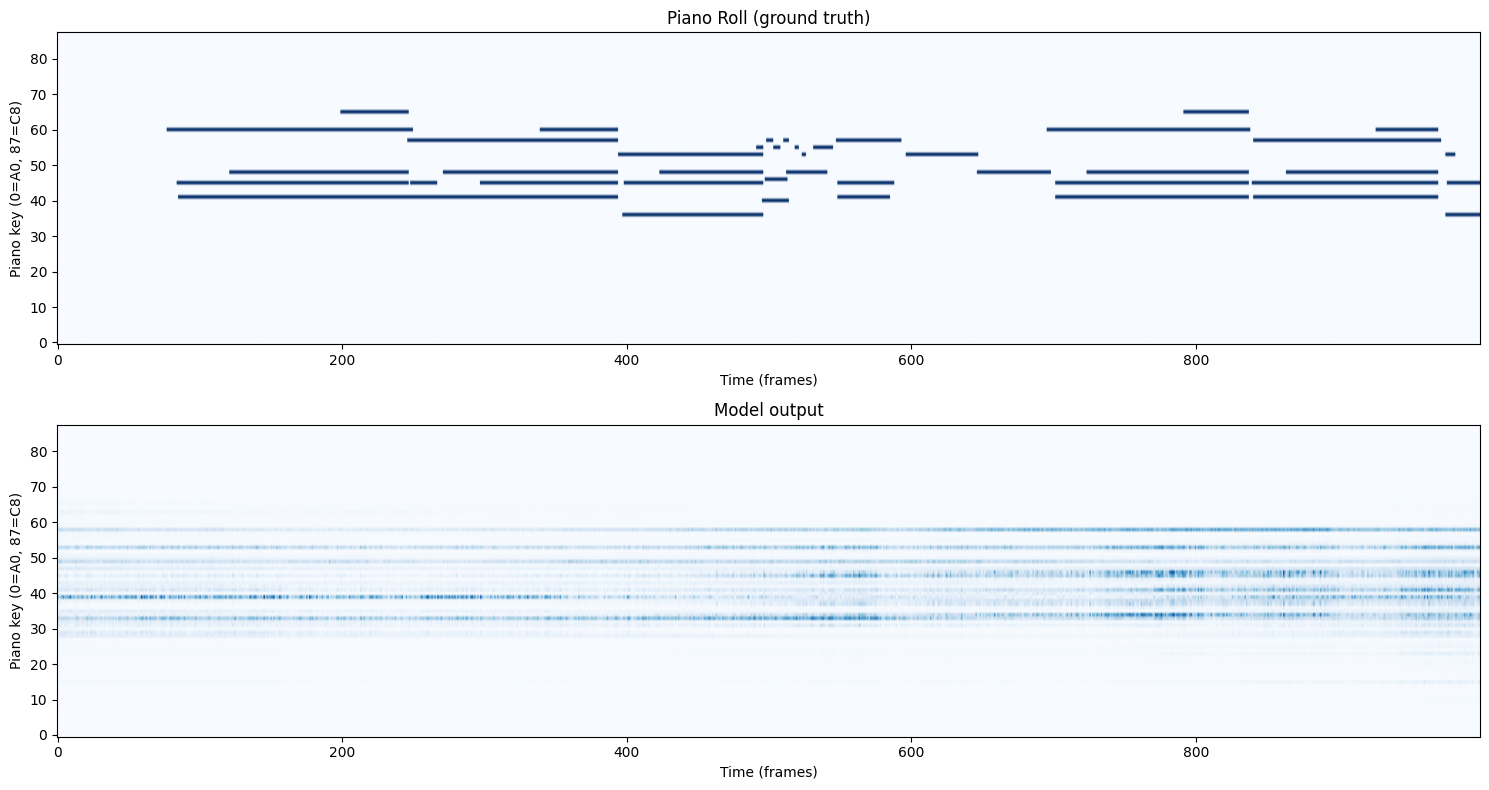

In [10]:
# Point to any single mp3 + midi pair
s_pair = {
    'audio_path': './data/mp3s/midi.mp3',
    'midi_path':  './data/midis/midi.mid',
    'duration': 26
    }
s_pair = {
    'audio_path': './data/mp3s/2018/MIDI-Unprocessed_Chamber2_MID--AUDIO_09_R3_2018_wav--1.mp3',
    'midi_path': './data/midis/2018/MIDI-Unprocessed_Chamber2_MID--AUDIO_09_R3_2018_wav--1.midi',
    'duration': 26
}

s_audio, s_roll = dataloader.load_pair(s_pair, start_sec=0)
s_cqt = preprocessor.compute(s_audio)

print(f"CQT shape:        {s_cqt.shape}")
print(f"Piano roll shape: {s_roll.shape}")

s_cqt_input = np.expand_dims(s_cqt, axis=0)    # (1, 84, 313, 1)
s_roll_input = np.expand_dims(s_roll, axis=0)  # (1, 88, 1000)

print(s_cqt_input.shape)
print(s_roll_input.shape)
s_pred = model.predict(s_cqt_input)
s_pred_rshp = np.reshape(s_pred, newshape=(88, 1000))
s_roll_rshp = np.reshape(s_roll, newshape=(88, 1000))
plotting.plot_pianoroll_in_vs_out(
    s_roll_rshp,
    s_pred_rshp)